In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
bus_speeds = pd.read_csv(
    "NYC\\raw\\MTA_Bus_Speeds__Beginning_2015_20260625.csv"
)

cbd_routes = pd.read_csv(
    "NYC\\raw\\MTA_Central_Business_District_Bus_Routes_20260625.csv"
)

In [17]:
display(bus_speeds.head())
display(cbd_routes.head())

,month,borough,day_type,trip_type,route_id,period,total_operating_time,total_mileage,average_speed
0,2015-01-01,Bronx,1,LCL/LTD,BX1,Off-Peak,"8,710,307","62,940,902.4",7.23
1,2015-01-01,Bronx,1,LCL/LTD,BX1,Peak,"4,334,312","30,316,503.6",6.99
2,2015-01-01,Bronx,2,LCL/LTD,BX1,Off-Peak,"2,498,651","18,742,158",7.50
3,2015-01-01,Bronx,2,LCL/LTD,BX1,Peak,"1,008,139","7,417,580.4",7.36
4,2015-01-01,Bronx,1,LCL/LTD,BX10,Off-Peak,"5,778,595","52,543,814.4",9.09


,Route ID,CBD Relation
0,BM1,Crossing CBD
1,BM2,Crossing CBD
2,BM3,Crossing CBD
3,BM4,Crossing CBD
4,BM5,Crossing CBD


In [18]:
bus_speeds.columns = bus_speeds.columns.str.strip()
cbd_routes.columns = cbd_routes.columns.str.strip()

In [19]:
display(bus_speeds.head(3))
display(cbd_routes.head(3))

,month,borough,day_type,trip_type,route_id,period,total_operating_time,total_mileage,average_speed
0,2015-01-01,Bronx,1,LCL/LTD,BX1,Off-Peak,"8,710,307","62,940,902.4",7.23
1,2015-01-01,Bronx,1,LCL/LTD,BX1,Peak,"4,334,312","30,316,503.6",6.99
2,2015-01-01,Bronx,2,LCL/LTD,BX1,Off-Peak,"2,498,651","18,742,158",7.50


,Route ID,CBD Relation
0,BM1,Crossing CBD
1,BM2,Crossing CBD
2,BM3,Crossing CBD


In [20]:
bus_speeds["month"] = pd.to_datetime(bus_speeds["month"])
bus_speeds["route_id"] = bus_speeds["route_id"].astype(str).str.strip().str.upper()
cbd_routes["Route ID"] = cbd_routes["Route ID"].astype(str).str.strip().str.upper()
bus_speeds["average_speed"] = pd.to_numeric(bus_speeds["average_speed"], errors="coerce")

# Relevant period for parallel trends
bus_speeds = bus_speeds[
    (bus_speeds["month"] >= "2023-01-01") & 
    (bus_speeds["month"] < "2025-01-05")
]

In [21]:
bus_speeds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30491 entries, 111451 to 141941
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   month                 30491 non-null  datetime64[ns]
 1   borough               30491 non-null  object        
 2   day_type              30491 non-null  int64         
 3   trip_type             30491 non-null  object        
 4   route_id              30491 non-null  object        
 5   period                30491 non-null  object        
 6   total_operating_time  30491 non-null  object        
 7   total_mileage         30491 non-null  object        
 8   average_speed         30491 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 2.3+ MB


In [22]:
cbd_routes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Route ID      107 non-null    object
 1   CBD Relation  107 non-null    object
dtypes: object(2)
memory usage: 1.8+ KB


In [23]:
cbd_routes = set(cbd_routes["Route ID"])
bus_speeds["cbd_route"] = bus_speeds["route_id"].isin(cbd_routes)

In [24]:
bus_speeds = bus_speeds[bus_speeds["day_type"] == 1]

In [25]:
monthly_trends = (
    bus_speeds.groupby(["month", "cbd_route"], as_index=False)["average_speed"]
    .mean()
)

monthly_trends["Group"] = monthly_trends["cbd_route"].map({
    True: "CBD routes", 
    False: "Non-CBD routes"
})

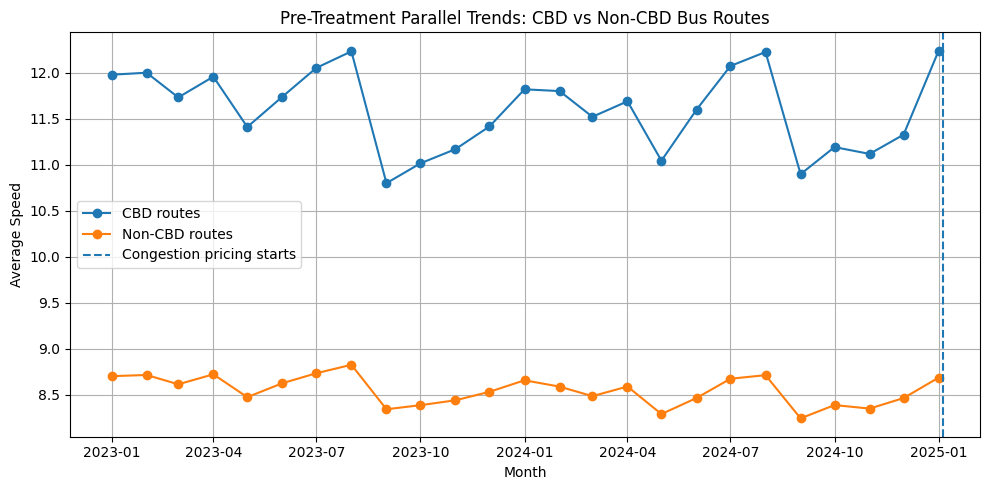

In [26]:
plt.figure(figsize=(10, 5))

for group, df in monthly_trends.groupby("Group"):
    plt.plot(df["month"], df["average_speed"], marker="o", label=group)

plt.axvline(pd.to_datetime("2025-01-05"), linestyle="--", label="Congestion pricing starts")

plt.title("Pre-Treatment Parallel Trends: CBD vs Non-CBD Bus Routes")
plt.xlabel("Month")
plt.ylabel("Average Speed")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()